# Temperature-programmed desorption (TPD)

TPD heats a dosed surface at a constant rate $T(t) = T_0 + \beta t$ and records the desorption rate as a function of temperature. For a desorption step $A^* \to A + *$ the rate follows the same coverage-dependent Arrhenius law `discopt.mkm` uses for any step,

$$ r(T) = -\frac{d\theta}{dt} = \nu\,\theta^{\,n}\,e^{-E_d/RT}, $$

with desorption order $n$, pre-exponential $\nu$, and desorption energy $E_d$. The **order leaves a fingerprint in the peak**: a first-order peak ($n=1$) sits at a temperature *independent* of the initial coverage, while a second-order peak ($n=2$) shifts to lower temperature as the coverage rises. We predict the first-order spectrum and then fit $\nu$ and $E_d$ to second-order data taken at several initial coverages.

In [1]:
%matplotlib inline

In [2]:
import numpy as np, jax, jax.numpy as jnp
jax.config.update('jax_enable_x64', True)
import pounce, matplotlib.pyplot as plt

R, beta, T0 = 8.617e-5, 1.0, 300.0          # eV/K, heating rate (K/s), start T
Tg = jnp.linspace(T0, 650.0, 400)            # temperature axis

def rk4(f, y0, ts):
    def step(y, tp):
        a, b = tp; h = b - a
        k1 = f(y, a); k2 = f(y + h/2*k1, a+h/2); k3 = f(y + h/2*k2, a+h/2); k4 = f(y + h*k3, b)
        yn = y + h/6*(k1 + 2*k2 + 2*k3 + k4); return yn, yn
    pairs = jnp.stack([ts[:-1], ts[1:]], 1); _, ys = jax.lax.scan(step, y0, pairs)
    return jnp.concatenate([y0[None], ys])

def tpd_rate(params, n, theta0):
    """Desorption rate vs temperature for order n and initial coverage theta0.

    params = [log10(nu), Ed]. Integrates dtheta/dT = -(nu/beta) e^{-Ed/RT} theta^n
    along the temperature ramp and returns r(T) = nu e^{-Ed/RT} theta(T)^n."""
    nu, Ed = 10**params[0], params[1]
    def rhs(theta, T):
        return -(nu/beta) * jnp.exp(-Ed/(R*T)) * jnp.clip(theta, 0.0, 1.0)**n
    theta = rk4(rhs, jnp.array(theta0), Tg)
    return nu * jnp.exp(-Ed/(R*Tg)) * jnp.clip(theta, 0.0, 1.0)**n

nu_true, Ed_true = 1e13, 1.0
p_true = jnp.array([np.log10(nu_true), Ed_true])
print(f'true desorption parameters:  nu = {nu_true:.0e} /s,  Ed = {Ed_true} eV')

true desorption parameters:  nu = 1e+13 /s,  Ed = 1.0 eV


## First order: the peak does not move with coverage

Predict the spectrum for three initial coverages. The peaks line up — a first-order TPD peak temperature is set by $\nu$, $E_d$, and the heating rate, not by how much was dosed.

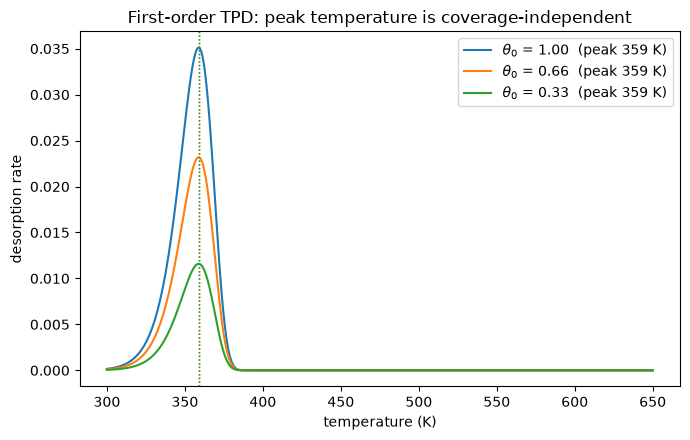

In [3]:
Tnp = np.asarray(Tg)
fig, ax = plt.subplots(figsize=(7, 4.5))
for c, col in zip([1.0, 0.66, 0.33], ['C0', 'C1', 'C2']):
    r = np.asarray(tpd_rate(p_true, 1, c))
    Tp = Tnp[r.argmax()]
    ax.plot(Tnp, r, col, label=fr'$\theta_0$ = {c:.2f}  (peak {Tp:.0f} K)')
    ax.axvline(Tp, color=col, ls=':', lw=1)
ax.set_xlabel('temperature (K)'); ax.set_ylabel('desorption rate')
ax.set_title('First-order TPD: peak temperature is coverage-independent'); ax.legend()
fig.tight_layout()

## Second order: the peak shifts, and we can fit it

For $n=2$ the peak moves to **lower** temperature as the initial coverage increases (two neighbours must meet to desorb, so a fuller surface desorbs sooner). That coverage dependence is exactly what makes $\nu$ and $E_d$ identifiable from a family of spectra. Generate synthetic second-order data at three coverages with a little noise:

In [4]:
theta0s = [1.0, 0.66, 0.33]
rng = np.random.default_rng(0)
clean = np.concatenate([np.asarray(tpd_rate(p_true, 2, c)) for c in theta0s])
data = clean + rng.normal(0, 0.03*clean.max(), clean.shape)
print(f'{len(theta0s)} spectra x {len(Tnp)} points = {data.size} measurements')

3 spectra x 400 points = 1200 measurements


Fit a single $(\nu, E_d)$ pair to all three spectra at once with POUNCE's `curve_fit` (analytic JAX Jacobian, so it reports confidence intervals):

In [5]:
sim = lambda p: jnp.concatenate([tpd_rate(jnp.array(p), 2, c) for c in theta0s])
res = pounce.curve_fit(lambda x, lognu, Ed: sim([lognu, Ed]),
                       np.arange(data.size), data, p0=[12.0, 0.8], jac='jax')
nu_fit, Ed_fit = 10**res.popt[0], res.popt[1]
print(f'fitted : nu = {nu_fit:.3g} /s  (true 1e13),  Ed = {Ed_fit:.4f} eV  (true 1.0)')
print(f'R^2 = {res.r_squared:.4f}')
print(f'95% CIs (log10 nu, Ed): {np.round(np.asarray(res.ci), 3).tolist()}')

fitted : nu = 8.78e+12 /s  (true 1e13),  Ed = 0.9956 eV  (true 1.0)
R^2 = 0.9757
95% CIs (log10 nu, Ed): [[12.79, 13.097], [0.985, 1.006]]


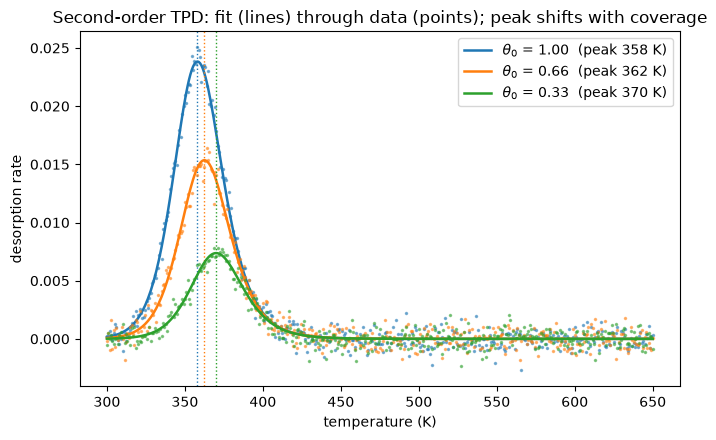

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for i, (c, col) in enumerate(zip(theta0s, ['C0', 'C1', 'C2'])):
    seg = slice(i*len(Tnp), (i+1)*len(Tnp))
    ax.plot(Tnp, data[seg], '.', color=col, ms=3, alpha=0.5)
    rfit = np.asarray(tpd_rate(res.popt, 2, c))
    Tp = Tnp[rfit.argmax()]
    ax.plot(Tnp, rfit, col, lw=1.8, label=fr'$\theta_0$ = {c:.2f}  (peak {Tp:.0f} K)')
    ax.axvline(Tp, color=col, ls=':', lw=1)
ax.set_xlabel('temperature (K)'); ax.set_ylabel('desorption rate')
ax.set_title('Second-order TPD: fit (lines) through data (points); peak shifts with coverage')
ax.legend(); fig.tight_layout()

## Takeaways

- TPD is a **non-isothermal transient** with a linear temperature ramp; the desorption rate is the same coverage-dependent Arrhenius law `discopt.mkm` uses for any step, $r = \nu\,\theta^n e^{-E_d/RT}$.
- **Order is diagnostic.** A first-order peak is coverage-independent; a second-order peak shifts to lower temperature with higher coverage. The shift is what makes the kinetics identifiable from a family of spectra.
- Writing the spectrum as a single JAX function of $(\log\nu, E_d)$ lets `pounce.curve_fit` recover both parameters (with confidence intervals) from noisy multi-coverage data via the analytic Jacobian — the same fitting pattern as the PRBS and multi-temperature notebooks.